<a href="https://colab.research.google.com/github/GR0409/Statistical-Learning-e21091/blob/main/Assignment_1_Basic_Notions_of_Probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q1) The Probability of Shooting at a Target

A point is chosen at random from a disk of radius $10$. Let $A$ be the event that the point lies within $1$ unit of the boundary.

1. Model the experiment assuming the point is uniformly distributed with respect to area, and compute $P(A)$.
2. Model the experiment assuming the distance to the point from the center is chosen uniformly from $[0,10]$, and the direction is chosen independently and uniformly from $[0,2\pi)$ and compute $P(A)$.
3. Explain why the two answers differ.


# 1. Model the experiment assuming the point is uniformly distributed with respect to area, and compute $P(A)$.


In [2]:
import numpy as np

def q1_part1_uniform_area(n_samples=1_000_000):

    # To simulate a uniform area distribution, the radius must be proportional
    # to the square root of a uniform distribution.
    r_area = 10 * np.sqrt(np.random.uniform(0, 1, n_samples))

    # point lies within 1 unit of the boundary (radius >= 9)
    prob_area = np.mean(r_area >= 9)

    print(f"P(A)   = {prob_area:.4f}")

q1_part1_uniform_area()

P(A)   = 0.1901


# 2. Model the experiment assuming the distance to the point from the center is chosen uniformly from $[0,10]$, and the direction is chosen independently and uniformly from $[0,2\pi)$ and compute $P(A)$.

In [3]:
import numpy as np

def q1_part2_uniform_radius(n_samples=1_000_000):

    # The radius is chosen uniformly between 0 and 10.
    r_radius = np.random.uniform(0, 10, n_samples)

    # point lies within 1 unit of the boundary (radius >= 9)
    prob_radius = np.mean(r_radius >= 9)

    print(f" P(A)   = {prob_radius:.4f}")

q1_part2_uniform_radius()

 P(A)   = 0.1002


# 3. Explain why the two answers differ.


The answers differ because each model defines random using a different probability distribution. The Area Model spreads points evenly across the entire surface, while the Radius Model forces a higher density of points toward the center, making the boundary significantly harder to hit.

# Q2) Bertrand's Paradox

A chord of a circle is chosen “at random.” What is the probability that its length exceeds the side length of the inscribed equilateral triangle?

Show that different mathematically natural models of “random chord” lead to different answers.

# Method 1 : Random Endpoints

Two random points on the circumference of the circle and draw a chord between them.

In [4]:
import numpy as np

def q2_method1_random_endpoints(n_samples=1_000_000):

    # Side length of an inscribed equilateral triangle in a unit circle (R=1)
    triangle_side = np.sqrt(3)

    # Generate two random angles around the circumference
    theta1 = np.random.uniform(0, 2*np.pi, n_samples)
    theta2 = np.random.uniform(0, 2*np.pi, n_samples)

    # Calculate chord length using the distance between the two points
    chord_lengths = 2 * np.sin(np.abs(theta1 - theta2) / 2)
    prob = np.mean(chord_lengths > triangle_side)

    print(f" Probability   = {prob:.4f}")

q2_method1_random_endpoints()

 Probability   = 0.3331


# Method 2 : Random Radius

A random radius of the circle, then choose a point uniformly along that radius to be the midpoint of the chord and draw the chord perpendicular to the radius.

In [5]:
import numpy as np

def q2_method2_random_radius(n_samples=1_000_000):

    triangle_side = np.sqrt(3)

    # Choose a random distance from the center [0, 1] to serve as the chord's midpoint
    r_midpoint = np.random.uniform(0, 1, n_samples)

    # Use the Pythagorean theorem to calculate the resulting chord length
    chord_lengths = 2 * np.sqrt(1 - r_midpoint**2)
    prob = np.mean(chord_lengths > triangle_side)

    print(f" Probability   = {prob:.4f}")

q2_method2_random_radius()

 Probability   = 0.4998


# Method 3: Random Midpoint

A random point uniformly distributed by area anywhere inside the circle to serve as the midpoint of the chord.

In [6]:
import numpy as np

def q2_method3_random_midpoint(n_samples=1_000_000):

    triangle_side = np.sqrt(3)

    # Choose a random midpoint uniformly by area.
    # Just like Q1 Part 1, uniform area requires the square root for the radius.
    r_area = np.sqrt(np.random.uniform(0, 1, n_samples))

    # Use the Pythagorean theorem to calculate the resulting chord length
    chord_lengths = 2 * np.sqrt(1 - r_area**2)
    prob = np.mean(chord_lengths > triangle_side)

    print(f" Probability   = {prob:.4f}")

q2_method3_random_midpoint()

 Probability   = 0.2495


#Q8) Probability of Being a Girl?

$G$ represent the event of a child being a girl, and $B$ represent the event of a child being a boy.
The sample space for the family having two children is:$S = \{(B, B), (B, G), (G, B), (G, G)\}$

Assuming the gender of each child is independent and equally are,
$P(G) = 1/2, P(B) = 1/2$

The probability is:$$P(G, G) = P(G) \times P(G) = \frac{1}{2} \times \frac{1}{2} = \frac{1}{4}$$$$P(G, B) = P(G) \times P(B) = \frac{1}{2} \times \frac{1}{2} = \frac{1}{4}$$$$P(B, G) = P(B) \times P(G) = \frac{1}{2} \times \frac{1}{2} = \frac{1}{4}$$$$P(B, B) = P(B) \times P(B) = \frac{1}{2} \times \frac{1}{2} = \frac{1}{4}$$

$X$ is both children are girls:$$X = \{(G, G)\}$$$$P(X) = \frac{1}{4}$$

$Y$ is the at least one child is a girl:$$Y = \{(G, G), (G, B), (B, G)\}$$$$P(Y) = P(G, G) + P(G, B) + P(B, G)$$$$P(Y) = \frac{1}{4} + \frac{1}{4} + \frac{1}{4} = \frac{3}{4}$$

The probability of both children being girls $P(X \mid Y)$:
$$P(X \mid Y) = \frac{P(X \cap Y)}{P(Y)}$$

$$X \cap Y = \{(G, G)\}$$$$P(X \cap Y) = \frac{1}{4}$$

$$P(X \mid Y) = \frac{1/4}{3/4}$$$$P(X \mid Y) = \frac{1}{4} \times \frac{4}{3}$$$$P(X \mid Y) = \frac{1}{3}$$

# Q9) Information Available in a Discrete Random Variable

A factory inspects a product and records its quality using two different coding systems.

Each product falls into exactly one of the following four categories:

* $G_1$: good quality, produced on Machine 1
* $G_2$: good quality, produced on Machine 2
* $D_1$: defective, produced on Machine 1
* $D_2$: defective, produced on Machine 2

Assume the sample space is

$$
\Omega=\{G_1,G_2,D_1,D_2\},
$$

with probabilities

$$
P(\{G_1\})=0.50,\qquad P(\{G_2\})=0.20,\qquad P(\{D_1\})=0.10,\qquad P(\{D_2\})=0.20.
$$

Define two discrete random variables on the same probability space:

* $X$ records only whether the item is good or defective:
  $$
  X(G_1)=0,\quad X(G_2)=0,\quad X(D_1)=1,\quad X(D_2)=1.
  $$

* $Y$ records both quality and machine:
  $$
  Y(G_1)=1,\quad Y(G_2)=2,\quad Y(D_1)=3,\quad Y(D_2)=4.
  $$

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$, where $\mathfrak F=\mathfrak P(\Omega)$.

$\Omega = \{G_1, G_2, D_1, D_2\}$

Since $\mathfrak{F} = \mathfrak{P}(\Omega)$ (the power set), it contains all $2^4 = 16$ possible subsets of $\Omega$.

$P(\{G_1\}) = 0.5$,  $P(\{G_2\}) = 0.2$,  $P(\{D_1\}) = 0.1$,  $P(\{D_2\}) = 0.2$

<br>
2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

$X = 0 \implies \{G_1, G_2\}$$X = 1 \implies \{D_1, D_2\}$

$\sigma(X) = \{\emptyset, \Omega, \{G_1, G_2\}, \{D_1, D_2\}\}$

<br>
3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

$Y = 1 \implies \{G_1\}$, $Y = 2 \implies \{G_2\}$, $Y = 3 \implies \{D_1\}$,$Y = 4 \implies \{D_2\}$

$\sigma(Y) = \mathfrak{P}(\Omega)$ (all 16 subsets)

<br>
4. Show that $\sigma(X)\subseteq \sigma(Y)$, and explain why $Y$ contains more information than $X$.

Every set in $\sigma(X)$ (which are $\emptyset, \Omega, \{G_1, G_2\}, \{D_1, D_2\}$) is also an element of the power set $\mathfrak{P}(\Omega)$.

Therefore, $\sigma(X) \subseteq \sigma(Y)$.

<br>
5. Find the marginal distribution of $X$.

$P(X = 0) = P(\{G_1, G_2\}) = 0.50 + 0.20 = \textbf{0.70}$

$P(X = 1) = P(\{D_1, D_2\}) = 0.10 + 0.20 = \textbf{0.30}$

<br>
6. Find the marginal distribution of $Y$.

$P(Y = 1) = P(\{G_1\}) = \textbf{0.50}$

$P(Y = 2) = P(\{G_2\}) = \textbf{0.20}$

$P(Y = 3) = P(\{D_1\}) = \textbf{0.10}$

$P(Y = 4) = P(\{D_2\}) = \textbf{0.20}$

<br>
7. Compute the joint probabilities
   $$
   P(X=0,Y=1),\quad P(X=0,Y=2),\quad P(X=1,Y=3),\quad P(X=1,Y=4).
   $$

$P(X=0, Y=1) = P(\{G_1, G_2\} \cap \{G_1\}) = P(\{G_1\}) = \textbf{0.50}$

$P(X=0, Y=2) = P(\{G_1, G_2\} \cap \{G_2\}) = P(\{G_2\}) = \textbf{0.20}$

$P(X=1, Y=3) = P(\{D_1, D_2\} \cap \{D_1\}) = P(\{D_1\}) = \textbf{0.10}$

$P(X=1, Y=4) = P(\{D_1, D_2\} \cap \{D_2\}) = P(\{D_2\}) = \textbf{0.20}$

<br>
8. Compute the conditional probabilities
   $$
   P(X=1\mid Y=3),\qquad P(X=1\mid Y=4),\qquad P(Y=3\mid X=1),\qquad P(Y=4\mid X=1).
   $$

$P(X=1 | Y=3) = \frac{P(X=1, Y=3)}{P(Y=3)} = \frac{0.10}{0.10} = \textbf{1}$

$P(X=1 | Y=4) = \frac{P(X=1, Y=4)}{P(Y=4)} = \frac{0.20}{0.20} = \textbf{1}$

$P(Y=3 | X=1) = \frac{P(X=1, Y=3)}{P(X=1)} = \frac{0.10}{0.30} = \mathbf{\frac{1}{3}}$

$P(Y=4 | X=1) = \frac{P(X=1, Y=4)}{P(X=1)} = \frac{0.20}{0.30} = \mathbf{\frac{2}{3}}$

<br>
9. Interpret the difference between conditioning on $X$ and conditioning on $Y$.

We know exactly which machine produced the item and its quality. Therefore, $X$ is perfectly predictable.But we only know the item is defective, but you don't know which machine made it. There is still uncertainty about $Y$

<br>
10. Explain, in words, what information is available in $\sigma(X)$ but not in $\sigma(Y)$, and what information is available in $\sigma(Y)$ but not in $\sigma(X)$.

In $\sigma(X)$ but not in $\sigma(Y)$ - None. Because $\sigma(X) \subseteq \sigma(Y)$, $Y$ contains all the information $X$ has.

In $\sigma(Y)$ but not in $\sigma(X)$ - The information about which machine produced the item. $\sigma(Y)$ can separate $G_1$ from $G_2$.

<br>
11. Give a Python based visualization of the model.



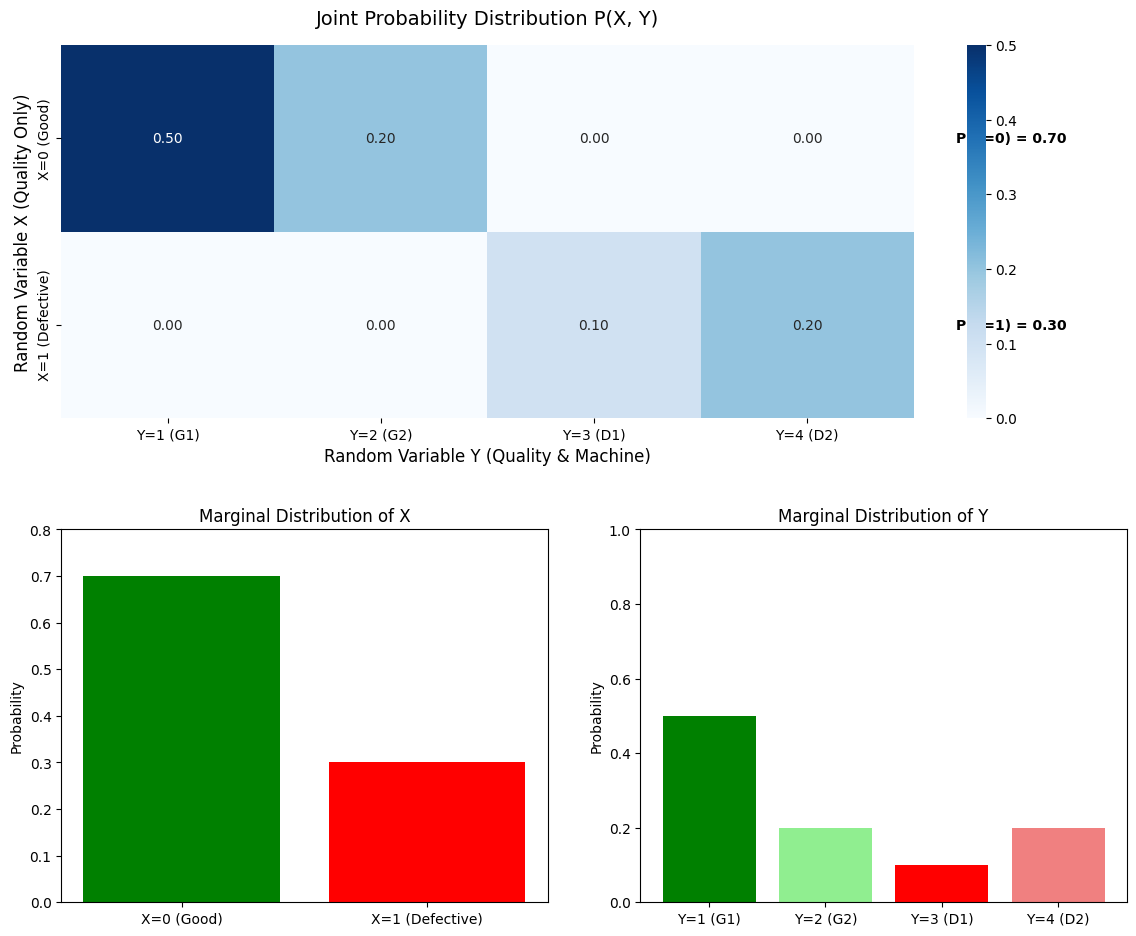

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_complete_model():
    # Joint Probabilities
    joint_probs = np.array([
        [0.50, 0.20, 0.00, 0.00],  # X = 0 (Good)
        [0.00, 0.00, 0.10, 0.20]   # X = 1 (Defective)
    ])

    # Marginal X Data
    x_labels = ['X=0 (Good)', 'X=1 (Defective)']
    x_probs = [0.70, 0.30]
    x_colors = ['green', 'red']

    # Marginal Y Data
    y_labels = ['Y=1 (G1)', 'Y=2 (G2)', 'Y=3 (D1)', 'Y=4 (D2)']
    y_probs = [0.50, 0.20, 0.10, 0.20]
    y_colors = ['green', 'lightgreen', 'red', 'lightcoral']

    # Using GridSpec to make the heatmap span the top row, and bar charts on the bottom
    fig = plt.figure(figsize=(12, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

    # Joint Probability Heatmap
    ax1 = fig.add_subplot(gs[0, :])
    sns.heatmap(joint_probs, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=y_labels, yticklabels=x_labels, cbar=True,
                vmin=0, vmax=0.5, ax=ax1)
    ax1.set_title('Joint Probability Distribution P(X, Y)', fontsize=14, pad=15)
    ax1.set_xlabel('Random Variable Y (Quality & Machine)', fontsize=12)
    ax1.set_ylabel('Random Variable X (Quality Only)', fontsize=12)

    # Add marginal texts to the side of the heatmap for clarity
    ax1.text(4.2, 0.5, f"P(X=0) = {np.sum(joint_probs[0]):.2f}", va='center', fontweight='bold')
    ax1.text(4.2, 1.5, f"P(X=1) = {np.sum(joint_probs[1]):.2f}", va='center', fontweight='bold')

    # Marginal Distribution of X
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.bar(x_labels, x_probs, color=x_colors)
    ax2.set_title('Marginal Distribution of X', fontsize=12)
    ax2.set_ylabel('Probability')
    ax2.set_ylim(0, 0.8)

    #  Marginal Distribution of Y
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.bar(y_labels, y_probs, color=y_colors)
    ax3.set_title('Marginal Distribution of Y', fontsize=12)
    ax3.set_ylabel('Probability')
    ax3.set_ylim(0, 1.0)

    # Adjust layout to prevent overlap
    plt.tight_layout(pad=3.0)
    plt.show()

visualize_complete_model()

# Q10) Information Available in Continuous Random Varaibles

A chemical plant monitors each production run using two different measurement systems.

For a given run, let

* $T$ be the deviation of the reactor temperature from target, measured in standardized units,
* $P$ be the deviation of the reactor pressure from target, also measured in standardized units.

Assume that $(T,P)$ is jointly continuous, with independent normal components:

$$
T \sim N(0,1), \qquad P \sim N(0,4),
$$

and $T$ and $P$ are independent.

Let the underlying probability space be

$$
\Omega=\mathbb R^2, \qquad \mathfrak F=\mathfrak B(\mathbb R^2),
$$

and let $P$ be the probability measure induced by the joint density

$$
f_{T,P}(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right), \qquad (t,p)\in\mathbb R^2.
$$

Define two random variables on the same probability space:

* $X:\Omega\to\mathbb R$ by
  $$
  X(t,p)=t,
  $$
  so that $X$ records only the reactor temperature deviation;

* $Y:\Omega\to\mathbb R^2$ by
  $$
  Y(t,p)=(t,p),
  $$
  so that $Y$ records the full sensor state: both temperature and pressure deviations.

Answer the following.



1. Write down the probability space $(\Omega,\mathfrak F,P)$ explicitly.

$\Omega = \mathbb{R}^2$

$\mathfrak{F} = \mathfrak{B}(\mathbb{R}^2)$

$$P(A) = \iint_A f_{T,P}(t,p) \,dt\,dp = \iint_A \frac{1}{4\pi} \exp\left(-\frac{t^2}{2} - \frac{p^2}{8}\right) \,dt\,dp$$

<br>
2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

$$\sigma(X) = \{X^{-1}(B) : B \in \mathfrak{B}(\mathbb{R})\}$$

$$X^{-1}(B) = \{(t,p) \in \mathbb{R}^2 : t \in B\} = B \times \mathbb{R}$$

So,
$$\sigma(X) = \{B \times \mathbb{R} : B \in \mathfrak{B}(\mathbb{R})\}$$

<br>
3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

$Y(t,p) = (t,p)$ on $\mathbb{R}^2$

$$\sigma(Y) = \{Y^{-1}(C) : C \in \mathfrak{B}(\mathbb{R}^2)\} = \{C : C \in \mathfrak{B}(\mathbb{R}^2)\}$$

$$\sigma(Y) = \mathfrak{B}(\mathbb{R}^2)$$

<br>
4. Show that
   $$
   \sigma(X)\subseteq \sigma(Y),
   $$
   and explain why $Y$ contains more information than $X$.

$A \in \sigma(X)$

$A = B \times \mathbb{R}$ for  $B \in \mathfrak{B}(\mathbb{R})$

$B \times \mathbb{R} \in \mathfrak{B}(\mathbb{R}^2)$

Since $\sigma(Y) = \mathfrak{B}(\mathbb{R}^2)$

$A \in \sigma(Y)$

$\sigma(X) \subseteq \sigma(Y)$

 $Y$ contains the exact values of both temperature ($t$) and pressure ($p$). $X$ only contains the temperature ($t$) and leaves pressure completely unrestricted ($\mathbb{R}$). Therefore, $Y$ contains complete information about the state of the reactor, while $X$ only contains partial information.


<br>
5. Find the marginal density of $X$.

$$f_X(x) = \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{x^2}{2}\right), \quad x \in \mathbb{R}$$


<br>
6. Find the marginal density of $Y$.

$$f_Y(t,p) = f_{T,P}(t,p) = \frac{1}{4\pi} \exp\left(-\frac{t^2}{2} - \frac{p^2}{8}\right), \quad (t,p) \in \mathbb{R}^2$$


<br>
7. Compute the following probabilities:
   $$
   P(X\leq 0), \qquad P(X>1), \qquad P(Y\in (-\infty,0]\times\mathbb R), \qquad P(Y\in [ -1,1]\times[-2,2]).
   $$

$$P(X \le 0) = \mathbf{0.5}$$ , $$P(X > 1) =  \mathbf{0.1587}$$

$$P(T \le 0, P \in \mathbb{R}) = P(X \le 0) = \mathbf{0.5}$$

$$P(-1 \le T \le 1) \times P(-2 \le P \le 2)$$

$$P(-2 \le P \le 2) = P\left(\frac{-2}{2} \le Z \le \frac{2}{2}\right) = P(-1 \le Z \le 1) \approx 0.6827$$

$$P = (\Phi(1) - \Phi(-1))^2 \approx 0.6827 \times 0.6827 \approx \mathbf{0.4661}$$

<br>
8. Compute the conditional distribution of $X$ given $Y=(t,p)$.

$P(X = t \mid Y = (t,p)) = 1$.

<br>
9. Compute the conditional distribution of $Y$ given $X=t$.

$$f_{Y|X}(y \mid x=t) = f_P(p) = \frac{1}{\sqrt{8\pi}} \exp\left(-\frac{p^2}{8}\right)$$

<br>
10. Explain, in words, what is known when one conditions on $X$ and what additional information becomes available when one conditions on $Y$.

Conditioning on $X$ is that we know exactly how much the reactor's temperature has deviated from the target, but the pressure deviation remains completely unknown and random.

Conditioning on $Y$ is that we know the exact deviation of both temperature and pressure. The additional information gained is the precise state of the reactor's pressure.

<br>
11. Show that
    $$
    X=\pi_1\circ Y,
    $$
    where $\pi_1(t,p)=t$, and explain why this implies that $X$ is a measurable function of $Y$.

$\pi_1(t,p) = t$

$$(\pi_1 \circ Y)(t,p) = \pi_1(Y(t,p)) = \pi_1(t,p) = t = X(t,p)$$

$X = \pi_1 \circ Y$

Because $Y$ is a random variable, meaning it is a measurable mapping. The composition of a measurable function ($\pi_1$) with a measurable mapping ($Y$) results in a measurable mapping. Therefore, $X$ is perfectly defined by the information generated by $Y$.

<br>
12. Give a Python-based visualization of the model, for example by plotting:

* the joint density of $Y=(T,P)$ as a contour plot or heat map;
* the marginal density of $X$;
* and a diagram illustrating that $\sigma(X)$ is coarser than $\sigma(Y)$.

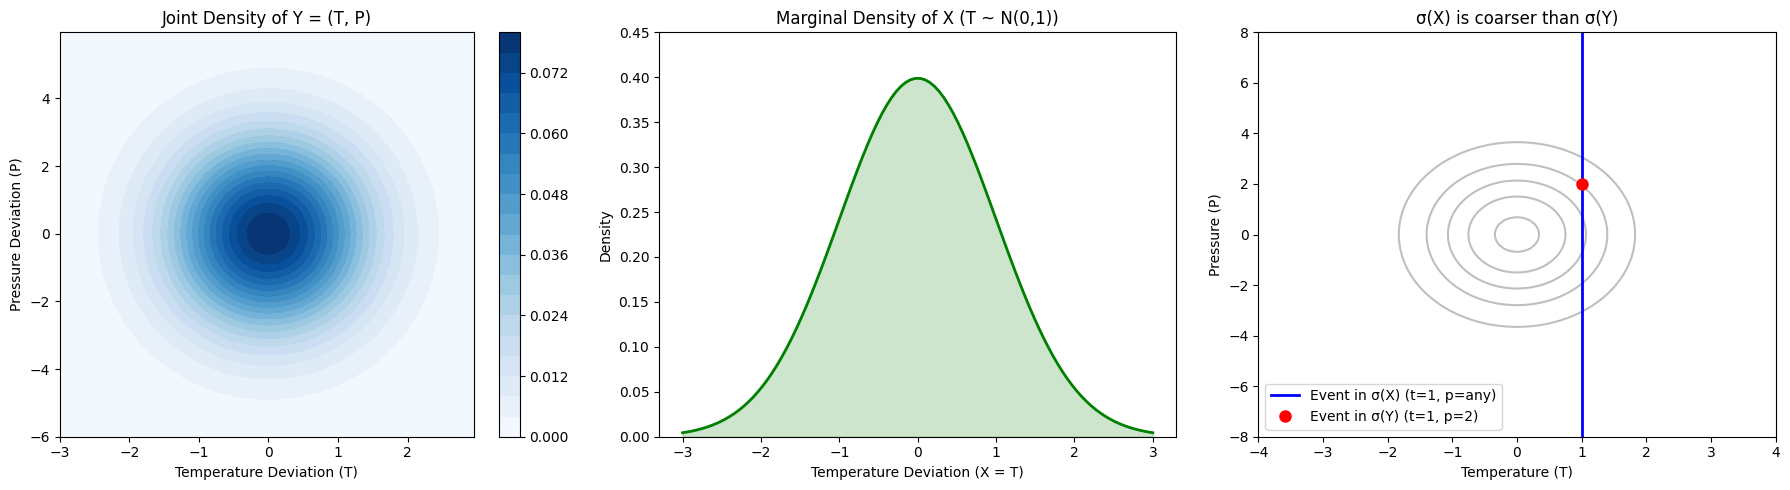

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal

def visualize_q10_part12():
    fig = plt.figure(figsize=(18, 5))

    # Joint Density of Y = (T, P)
    ax1 = fig.add_subplot(1, 3, 1)
    t, p = np.mgrid[-3:3:.05, -6:6:.05]
    pos = np.dstack((t, p))
    # T ~ N(0,1), P ~ N(0,4)
    rv = multivariate_normal([0, 0], [[1, 0], [0, 4]])

    contour = ax1.contourf(t, p, rv.pdf(pos), cmap='Blues', levels=20)
    fig.colorbar(contour, ax=ax1)
    ax1.set_title('Joint Density of Y = (T, P)')
    ax1.set_xlabel('Temperature Deviation (T)')
    ax1.set_ylabel('Pressure Deviation (P)')

    # Marginal Density of X
    ax2 = fig.add_subplot(1, 3, 2)
    x_vals = np.linspace(-3, 3, 100)
    ax2.plot(x_vals, norm.pdf(x_vals, 0, 1), 'g-', lw=2)
    ax2.fill_between(x_vals, norm.pdf(x_vals, 0, 1), alpha=0.2, color='green')
    ax2.set_title('Marginal Density of X (T ~ N(0,1))')
    ax2.set_xlabel('Temperature Deviation (X = T)')
    ax2.set_ylabel('Density')
    ax2.set_ylim(0, 0.45)

    ax3 = fig.add_subplot(1, 3, 3)

    # Create the grid
    t_range = np.linspace(-4, 4, 100)
    p_range = np.linspace(-8, 8, 100)
    T_grid, P_grid = np.meshgrid(t_range, p_range)
    pos_grid = np.dstack((T_grid, P_grid))

    # Plot the background contours
    ax3.contour(T_grid, P_grid, rv.pdf(pos_grid), colors='grey', alpha=0.5, levels=5)

    # Plot Event in sigma(X)
    ax3.axvline(x=1, color='blue', linewidth=2, label='Event in σ(X) (t=1, p=any)')

    # Plot Event in sigma(Y)
    ax3.plot(1, 2, 'ro', markersize=8, label='Event in σ(Y) (t=1, p=2)')

    ax3.set_title('σ(X) is coarser than σ(Y)')
    ax3.set_xlabel('Temperature (T)')
    ax3.set_ylabel('Pressure (P)')
    ax3.set_xlim(-4, 4)
    ax3.set_ylim(-8, 8)
    ax3.legend(loc='lower left')

    ax3.grid(False)

    plt.tight_layout()
    plt.show()

visualize_q10_part12()